In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
# ── Global style ──────────────────────────
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 20,
    "axes.titlesize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 10.5,
    "legend.frameon": False,      
    "axes.grid": False,           
    "lines.linewidth": 1.8,
    "lines.markersize": 6.5,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})

PANEL_LABEL_KW = dict(loc="center", fontsize=18, fontweight="normal")

_tab10 = plt.cm.tab10.colors
TAB_COLORS = [_tab10[2], _tab10[0], "#6a3d9a", "#c2185b"] + [c for i, c in enumerate(_tab10) if i not in (0, 2)]

In [3]:
# ── Shared parameters ────────────────────────────────────────────
h2, beta, Erange = 1.10, 0.00, 0.30
N_B = 2
N_A_values = [1, 2, 3, 4]

L_values    = [12, 13, 15, 16]
k_values    = [1000, 1000, 2000, 2000]
N_AB_values = [9, 10, 11, 12]

In [4]:
# ── Data loaders ─────────────
def load_fixed_VB(N_A, N_B, h2, beta, Erange, squared):
    tag = "" if squared else "_n1"
    path = (
        f"h2_{h2:.2f}/"
        f"trace_norm_distance_exact{tag}"
        f"_N_A_{N_A:d}_N_B_{N_B:d}"
        f"_beta_{beta:.2f}_Erange_{Erange:.2f}.csv"
    )
    return pd.read_csv(path)


def load_fixed_VAB_ratio(L, k, N_AB, h2, beta, squared):
    tag = "" if squared else "_n1"
    path = (
        f"h2_{h2:.2f}/"
        f"trace_norm_distance_exact{tag}_L_{L:d}_N_AB_{N_AB:d}"
        f"_beta_{beta:.2f}_k_{k:d}_Erange_{Erange:.2f}.csv"
    )
    return pd.read_csv(path)

In [5]:
# ── Y-axis labels ───────────────────────
YLABEL_UNSQ = r"$\ln\!\left[D(\rho_{AA^*,\,i},\,[\rho_{AA^*}])\right]$"
YLABEL_SQ   = r"$\ln\!\left[D(\rho_{AA^*,\,i}^{(2)},\,[\rho_{AA^*}^{(2)}])\right]$"

In [6]:
# ── Panel plotting functions ─────────────────────────────────────────────────
def plot_panel_fixed_VB(ax, squared):
    """(a)/(b): x = V, one line per V_A."""
    col = "normalized_trace_norm_distance" if squared else "trace_norm_distance"

    datasets = {}
    for N_A in N_A_values:
        try:
            datasets[N_A] = load_fixed_VB(N_A, N_B, h2, beta, Erange, squared)
        except FileNotFoundError:
            print(f"[fixed_VB] file not found for N_A={N_A} — skipping")

    colors = TAB_COLORS[: len(datasets)]
    for color, (N_A, df) in zip(colors, datasets.items()):
        V = df["L"].values
        y = np.log(df[col].values)
        fit = linregress(V, y)
        x_fit = np.linspace(V.min(), V.max(), 200)
        ax.scatter(V, y, color=color, zorder=3)
        ax.plot(x_fit, fit.slope * x_fit + fit.intercept, color=color,
                 label=fr"$V_A={N_A}$")

    ax.set_xlabel(r"$V$")
    ax.set_ylabel(YLABEL_SQ if squared else YLABEL_UNSQ)
    ax.legend(ncol=2)


def plot_panel_fixed_VAB_ratio(ax, squared):
    """(c)/(d): x = V_A, one line per (V, V_AB)."""
    col = "normalized_trace_norm_distance" if squared else "trace_norm_distance"

    datasets = {}
    for L, k, N_AB in zip(L_values, k_values, N_AB_values):
        try:
            datasets[(L, k, N_AB)] = load_fixed_VAB_ratio(L, k, N_AB, h2, beta, squared)
        except FileNotFoundError:
            print(f"[fixed_VAB_ratio] file not found for L={L}, N_AB={N_AB} — skipping")

    colors = TAB_COLORS[: len(datasets)]
    for color, ((L, k, N_AB), df) in zip(colors, datasets.items()):
        N_A = df["N_A"].values
        y = np.log(df[col].values)
        fit = linregress(N_A, y)
        x_fit = np.linspace(N_A.min(), N_A.max(), 200)
        ax.scatter(N_A, y, color=color, zorder=3)
        ax.plot(x_fit, fit.slope * x_fit + fit.intercept, color=color,
                 label=fr"$V={L}$, $V_{{AB}}={N_AB}$")

    ax.set_xlabel(r"$V_A$")
    ax.set_ylabel(YLABEL_SQ if squared else YLABEL_UNSQ)
    ax.legend()

In [7]:
# ── Assemble the combined figure ─────────────────────────────────────────────
def build_figure():
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.3))

    plot_panel_fixed_VB(axes[0], squared=False)
    plot_panel_fixed_VB(axes[1], squared=True)
    plot_panel_fixed_VAB_ratio(axes[2], squared=False)
    plot_panel_fixed_VAB_ratio(axes[3], squared=True)

    for ax, letter in zip(axes, "abcd"):
        ax.set_title(f"({letter})", **PANEL_LABEL_KW)

    fig.tight_layout()
    return fig

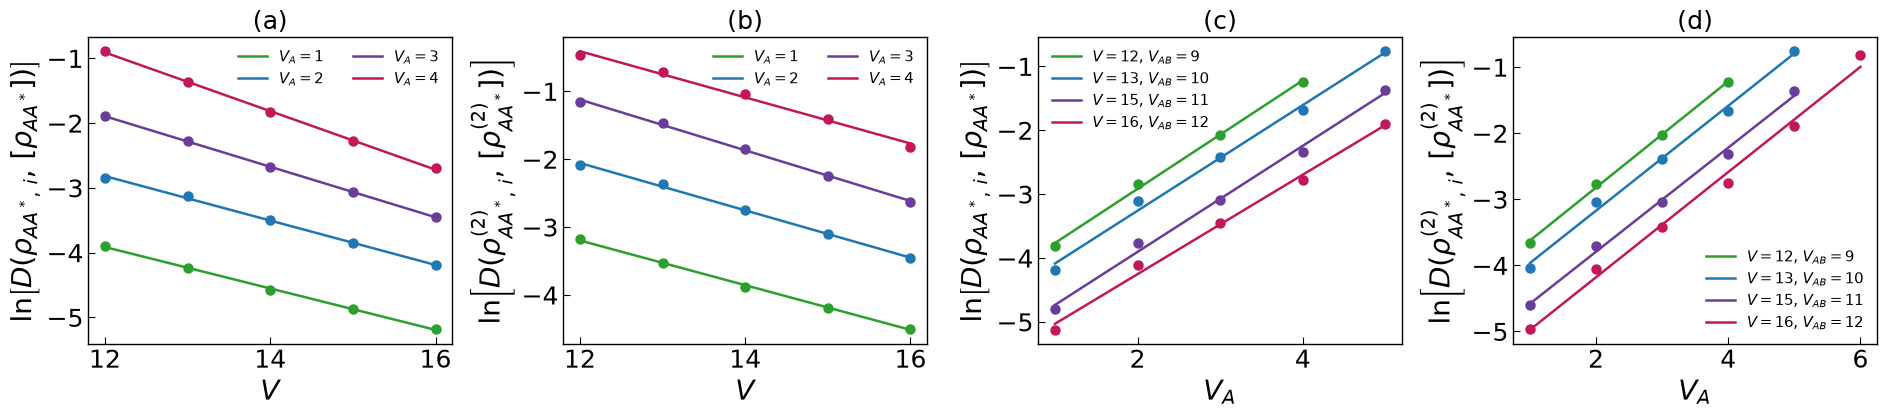

In [8]:
fig1 = build_figure()
fig1.savefig("fig_7.pdf", bbox_inches="tight")
plt.show()